In [1]:
import pandas as pd

df = pd.read_csv("results_env_onset/sub-004/sub-004_backward_mtrf_env_onset.trial_results.csv")

print(df[["diff_envelope", "diff_onset", "correct"]])
print("env only:", (df["diff_envelope"] > 0).mean())
print("onset only:", (df["diff_onset"] > 0).mean())
print("combined:", df["correct"].mean())
print("mean diff envelope:", df["diff_envelope"].mean())
print("mean diff onset:", df["diff_onset"].mean())

    diff_envelope  diff_onset  correct
0       -0.085302   -0.081691    False
1        0.023324    0.054647     True
2       -0.025908    0.018439    False
3       -0.000562    0.004870     True
4        0.078551    0.025500     True
5       -0.051503   -0.000307    False
6       -0.075127   -0.085235    False
7        0.024189   -0.010858     True
8       -0.040312   -0.081195    False
9        0.005360   -0.011886    False
10       0.064811   -0.030333     True
11      -0.009648    0.004894    False
12      -0.054228    0.001159    False
13       0.014453    0.023518     True
14       0.037431    0.087689     True
15       0.029999    0.077838     True
16      -0.125119   -0.096511    False
17       0.010035   -0.092648    False
18      -0.022891   -0.004309    False
19      -0.025076   -0.023914    False
20       0.071702    0.081510     True
21       0.125187    0.173846     True
22      -0.067271   -0.069028    False
23      -0.008040   -0.044530    False
24       0.222368    0.10

In [2]:
print("Envelope-only:",
      (df["diff_envelope"] > 0).mean())

print("Onset-only:",
      (df["diff_onset"] > 0).mean())

print("Combined:",
      df["correct"].mean())

Envelope-only: 0.4375
Onset-only: 0.46875
Combined: 0.4375


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
import math

# -----------------------------
# 1. Paths
# -----------------------------

participants_path = Path(r"C:\subset\ds-eeg-snhl\participants.tsv")

# Change this to where your results are stored
results_dir = Path(r"..\results_backward")

# -----------------------------
# 2. Choose group
# -----------------------------

# Options:
# hearing_status: "hi" or "nh"
# ear_eeg: "yes" or "no"

wanted_hearing_status = "nh"
wanted_ear_eeg = "yes"

# -----------------------------
# 3. Load participant metadata
# -----------------------------

participants = pd.read_csv(participants_path, sep="\t")

participants["hearing_status"] = participants["hearing_status"].str.lower()
participants["ear_eeg"] = participants["ear_eeg"].str.lower()

group_df = participants[
    (participants["hearing_status"] == wanted_hearing_status) &
    (participants["ear_eeg"] == wanted_ear_eeg)
]

subjects = group_df["participant_id"].tolist()

print("Selected subjects:")
print(subjects)
print("Number of subjects:", len(subjects))

# -----------------------------
# 4. Load decoder weights
# -----------------------------

subject_maps = {}

for sub in subjects:
    npz_path = results_dir / sub / f"{sub}_backward_eelbrain_backward_predictions.npz"

    if not npz_path.exists():
        print("Missing file:", npz_path)
        continue

    data = np.load(npz_path)
    decoder_h = data["decoder_h"]  # shape: channels x lags

    # Collapse over time-lags to get one value per channel
    spatial_weights = np.sqrt(np.mean(decoder_h ** 2, axis=1))

    subject_maps[sub] = spatial_weights

print("Number of loaded subjects:", len(subject_maps))

Selected subjects:
['sub-021', 'sub-022', 'sub-023', 'sub-024', 'sub-025', 'sub-026', 'sub-027', 'sub-028', 'sub-029', 'sub-030']
Number of subjects: 10
Number of loaded subjects: 10


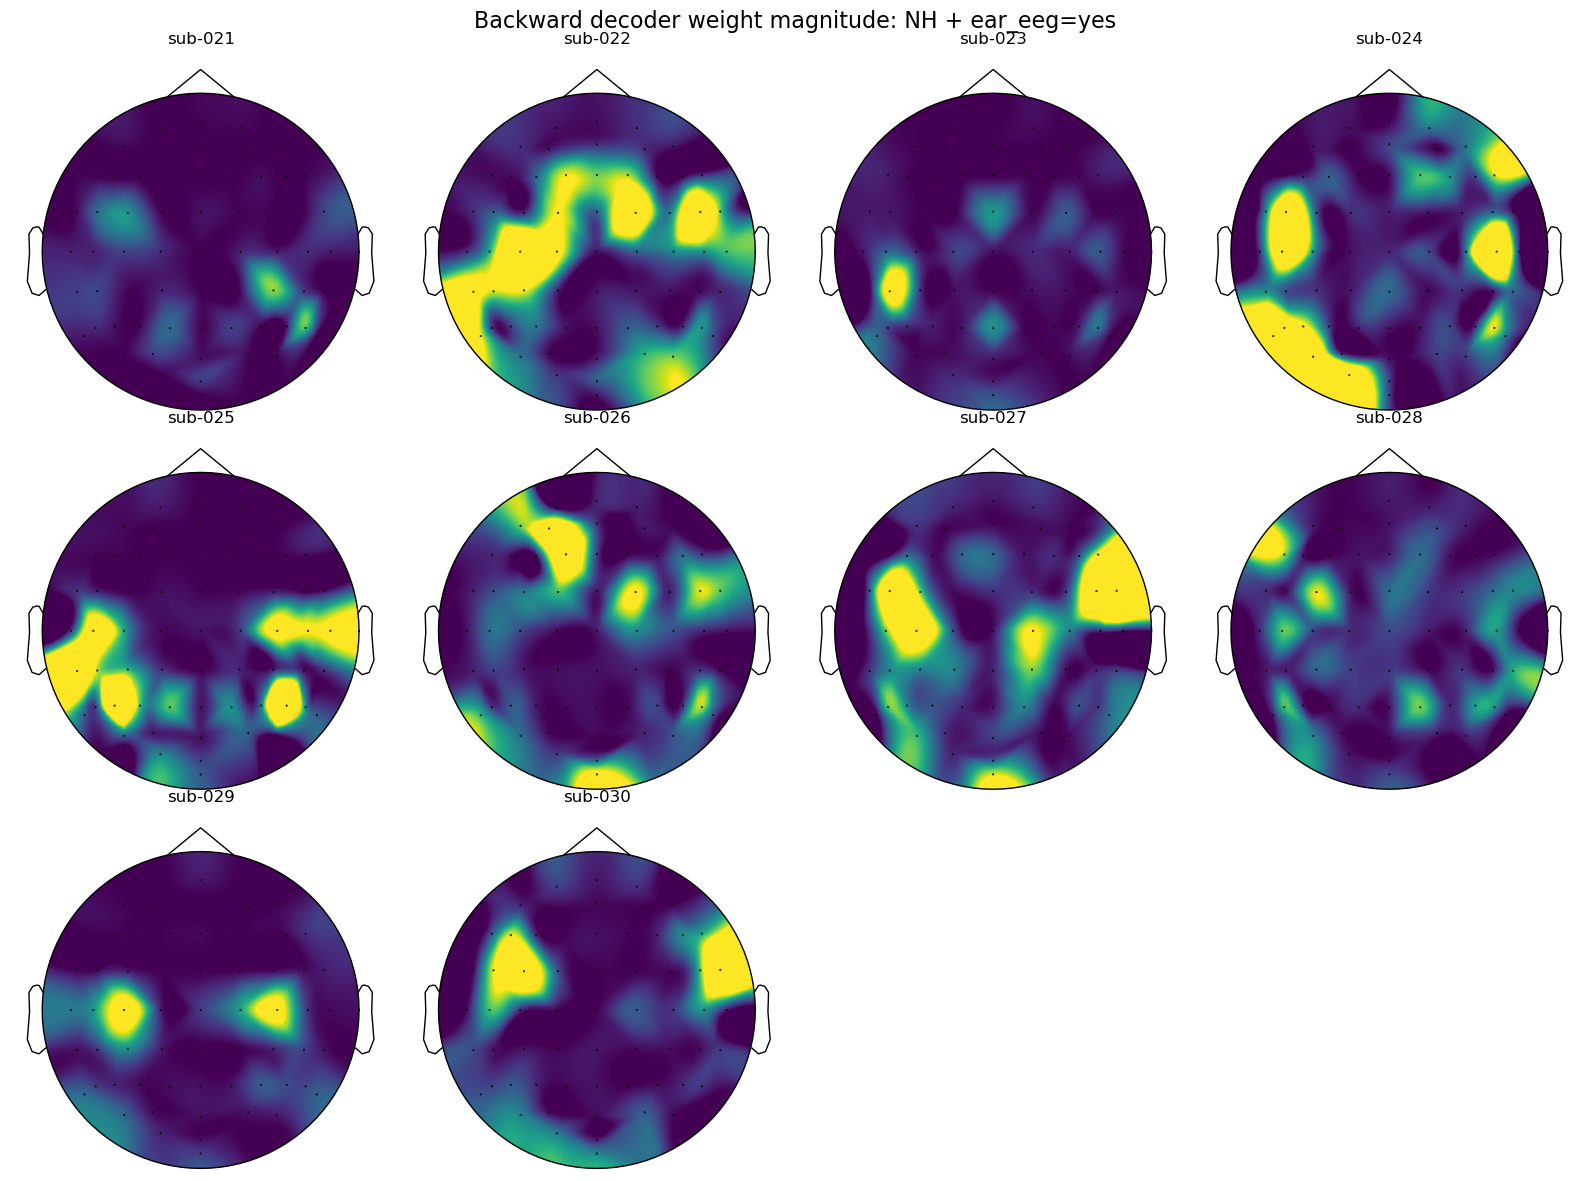

In [38]:
# -----------------------------
# 5. Create EEG montage/info
# -----------------------------

montage = mne.channels.make_standard_montage("biosemi64")

# Important:
# This is a temporary assumption.
# You should replace this with the exact channel names and order used in your model.
n_channels = len(next(iter(subject_maps.values())))
ch_names = montage.ch_names[:n_channels]

info = mne.create_info(ch_names=ch_names, sfreq=64, ch_types="eeg")
info.set_montage(montage, on_missing="ignore")

# -----------------------------
# 6. Plot topomap grid
# -----------------------------

n_subjects = len(subject_maps)

n_cols = 4
n_rows = math.ceil(n_subjects / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

# Use same color scale across all subjects
all_values = np.concatenate(list(subject_maps.values()))
vmin = np.percentile(spatial_weights,5)
vmax = np.percentile(spatial_weights,95)

for ax, (sub, spatial_weights) in zip(axes, subject_maps.items()):
    mne.viz.plot_topomap(
        spatial_weights,
        info,
        axes=ax,
        show=False,
        contours=0,
        cmap="viridis",
        vlim=(vmin, vmax)
    )
    ax.set_title(sub)

# Turn off unused axes
for ax in axes[len(subject_maps):]:
    ax.axis("off")

fig.suptitle(
    f"Backward decoder weight magnitude: {wanted_hearing_status.upper()} + ear_eeg={wanted_ear_eeg}",
    fontsize=16
)

plt.tight_layout()
plt.show()